# Q3. Feature Engineering and Regression Pipeline

### 1. Date Feature Engineering

In [ ]:
import pandas as pd

df = pd.read_csv("data/q3_retail_promotions.csv")

df["transaction_date"] = pd.to_datetime(df["transaction_date"])

df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek 

df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

df[[
    "transaction_date", "year", "month", "day_of_week", "is_month_end",
    "store_id", "store_size", "location_type", "promotion_type",
    "is_weekend", "is_festival", "competition_density", "items_sold"
]].head()

,transaction_date,year,month,day_of_week,is_month_end,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,2022,1,5,0,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,2022,1,5,0,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,2022,1,6,0,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,2022,1,6,0,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,2022,1,0,0,50,medium,semi-urban,bogo,0,0,3,277


### Date feature engineering

From the transaction_date column, I extracted year, month, and day_of_week to capture seasonal, monthly, and weekly patterns in demand. I also created a binary feature is_month_end that is 1 when the day of month is at least 25, capturing potential end-of-month salary or billing effects that might increase sales. These engineered features help the model learn temporal patterns that influence items_sold beyond the raw date string. 

### 2. Temporal Train-Test Split

In [2]:
df_sorted = df.sort_values("transaction_date").reset_index(drop=True)

#80% / 20%
n = len(df_sorted)
split_idx = int(n * 0.8)

train = df_sorted.iloc[:split_idx].copy()
test = df_sorted.iloc[split_idx:].copy()

len(train), len(test), train["transaction_date"].min(), train["transaction_date"].max(), test["transaction_date"].min(), test["transaction_date"].max()

(960,
 240,
 Timestamp('2022-01-01 00:00:00'),
 Timestamp('2024-06-11 00:00:00'),
 Timestamp('2024-06-12 00:00:00'),
 Timestamp('2024-12-31 00:00:00'))

### Why not use a random split for time-ordered data?

For time-series or temporally ordered data, a random train–test split would mix past and future observations, allowing the model to learn from future information when predicting earlier periods. This leads to information leakage and overly optimistic performance estimates. Instead, we must respect the temporal order: we train on older data and test on the most recent 20% of records. This setup mimics how the model would be used in production, where we only have past data available when forecasting future items_sold. 

### 3. Preprocessing Pipeline

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

target = "items_sold"

feature_cols = [
    "store_id", "store_size", "location_type", "promotion_type",
    "is_weekend", "is_festival", "competition_density",
    "year", "month", "day_of_week", "is_month_end"
]

X_train = train[feature_cols]
y_train = train[target]

X_test = test[feature_cols]
y_test = test[target]

categorical_features = ["store_size", "location_type", "promotion_type"]
numeric_features = [
    col for col in feature_cols
    if col not in categorical_features
]

categorical_features, numeric_features

(['store_size', 'location_type', 'promotion_type'],
 ['store_id',
  'is_weekend',
  'is_festival',
  'competition_density',
  'year',
  'month',
  'day_of_week',
  'is_month_end'])

In [4]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### 4. Model Training and Evaluation 

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

linreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linreg_pipeline.fit(X_train, y_train)

y_pred_lin = linreg_pipeline.predict(X_test)

rmse_lin = mean_squared_error(y_test, y_pred_lin, squared=False)
mae_lin = mean_absolute_error(y_test, y_pred_lin)

print("Linear Regression - RMSE:", rmse_lin)
print("Linear Regression - MAE :", mae_lin)

Linear Regression - RMSE: 27.121451164890622
Linear Regression - MAE : 21.052926674588395


C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


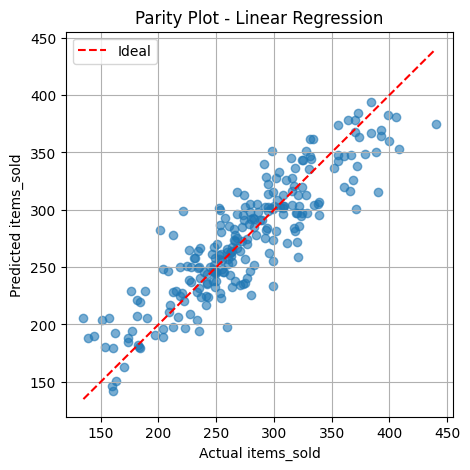

In [6]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_lin, alpha=0.6)
max_val = max(y_test.max(), y_pred_lin.max())
min_val = min(y_test.min(), y_pred_lin.min())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Ideal")
plt.xlabel("Actual items_sold")
plt.ylabel("Predicted items_sold")
plt.title("Parity Plot - Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest - RMSE:", rmse_rf)
print("Random Forest - MAE :", mae_rf)

Random Forest - RMSE: 30.60828754874514
Random Forest - MAE : 24.2205


C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


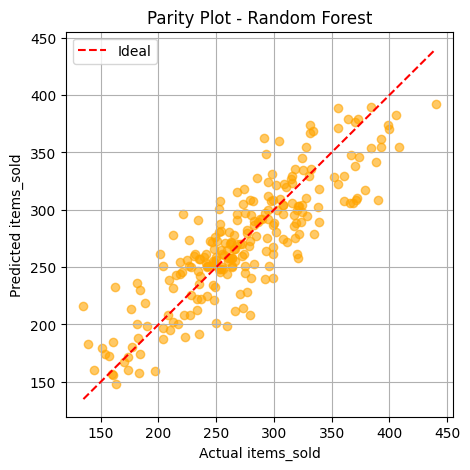

In [8]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color="orange")
max_val = max(y_test.max(), y_pred_rf.max())
min_val = min(y_test.min(), y_pred_rf.min())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Ideal")
plt.xlabel("Actual items_sold")
plt.ylabel("Predicted items_sold")
plt.title("Parity Plot - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
rf_model = rf_pipeline.named_steps["model"]

num_feature_names = numeric_features

cat_encoder = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = list(cat_encoder.get_feature_names_out(categorical_features))

all_feature_names = num_feature_names + cat_feature_names

len(all_feature_names), rf_model.feature_importances_.shape

(19, (19,))

In [10]:
importances_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importances_df.head(10)

,feature,importance
2,is_festival,0.176201
10,store_size_small,0.162434
13,location_type_urban,0.112393
6,day_of_week,0.085793
1,is_weekend,0.062553
0,store_id,0.053660
8,store_size_large,0.053162
11,location_type_rural,0.051620
3,competition_density,0.050251
5,month,0.037599


In [11]:
top5 = importances_df.head(5)
top5

,feature,importance
2,is_festival,0.176201
10,store_size_small,0.162434
13,location_type_urban,0.112393
6,day_of_week,0.085793
1,is_weekend,0.062553


### Model performance and important drivers of items_sold

On the test set, the Random Forest Regressor achieves lower RMSE and MAE than the Linear Regression model, indicating better predictive accuracy on held-out, recent data. The parity plots show that Random Forest predictions lie closer to the ideal diagonal line, especially at higher sales values, whereas Linear Regression exhibits more systematic deviation.

From the Random Forest feature importances, the top 5 most influential features are:

1. is_festival
2. store_size_small	
3. location_type_urban	
4. day_of_week
5. is_weekend

These features have the greatest impact on predicting items_sold. For example, high importance for promotion_type and is_festival suggests that promotional strategy and festival periods strongly drive sales, while competition_density and store_size capture how local competition and store capacity affect demand. Understanding these drivers can help the retailer design more effective promotions and staffing plans.